# 04 – DeBERTa NER: Original vs RAG-Cleaned Labels

## Notebook Overview

This notebook replicates the controlled experiment from Notebook 03 using **DeBERTa-v3-base** (LR=2e-5, BATCH=16, EPOCHS=15, no weighted loss) — the best-performing model in this project on the original benchmark.

The core question is whether label cleaning improves a pre-trained Transformer model, and to what extent the improvement differs from the BiLSTM baseline established in Notebook 03.

> *High performance on noisy data does not necessarily reflect correct understanding, but rather consistency with annotation artifacts.*

Two controlled experiments are run with identical hyperparameters, seeds, and preprocessing:

- **Experiment 1** — train on original labels, evaluate on original test set
- **Experiment 2** — train on RAG-cleaned labels (Notebook 02), evaluate on the original test set (Setting 1 — main benchmark) and on the cleaned test set (Setting 2 — auxiliary analysis)

The only variable that changes between experiments is the source of training labels. Any difference in performance can therefore be attributed solely to label quality.

# Part 1 — Theoretical Background

## 1) Annotation Noise and Experimental Design

The annotation noise problem and the experimental design are described in detail in Notebook 03, Section 1. The same two-experiment setup is replicated here: Experiment 1 trains and evaluates on original labels; Experiment 2 trains on RAG-cleaned labels and evaluates under both Setting 1 (original test) and Setting 2 (cleaned test). All hyperparameters, seeds, and preprocessing steps are held constant — the only variable is the source of training labels.

## 2) From Static to Contextual Representations

Unlike GloVe, which assigns a fixed vector to each word type regardless of context, Transformer-based models produce **contextualised** token representations. The self-attention mechanism allows each token to attend to every other token in the sequence:

$$\text{Attention}(Q, K, V) = \text{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}}\right) V$$

Stacking multiple self-attention layers enables the model to build increasingly abstract contextual representations, capturing long-range dependencies that are difficult for recurrent architectures to model reliably.

## 3) DeBERTa

**DeBERTa** (He et al., 2021) improves over BERT through two architectural contributions. First, **disentangled attention** encodes content and position separately, computing attention scores using four interaction terms (content-to-content, content-to-position, position-to-content, position-to-position). This allows the model to more precisely represent relative positional relationships — particularly useful for technical entities such as `"15.6-inch"` or `"i7-1165G7"` where position carries semantic information. Second, an **enhanced mask decoder** reintroduces absolute position information at the output layer before the prediction head.

**DeBERTa-v3** replaces masked language modelling with **ELECTRA-style replaced token detection**: a generator produces plausible token substitutions, and the discriminator learns to identify replaced tokens at every position. This provides a denser training signal than standard MLM, where only 15% of tokens contribute to the loss.

## 4) Subword Alignment for NER

DeBERTa tokenises input with SentencePiece. A single word may split into multiple subword tokens (e.g., *i7-1165G7* → [`i7`, `-`, `1165`, `G7`]). For NER, BIO labels are aligned to subword tokens: the first subword of each word receives the gold label; subsequent subwords are assigned `-100` and ignored in the loss. At inference, only first-subword predictions are used for span extraction.

## 5) Evaluation

NER performance is measured at the entity span level using exact-match micro F1, as defined in Notebook 03, Section 3. The original test set serves as the primary benchmark; the cleaned test set is reported as secondary analysis.

# Part 2 — Model Pipeline

## 6) Setup

In [ ]:
# !pip install -q transformers sentencepiece protobuf==4.25.3

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import json
import os
import sys
import re
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer,
    AutoModelForTokenClassification,
    get_linear_schedule_with_warmup,
)
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 100

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
sys.stdout.flush()

Device: cpu


## 7) Paths and hyperparameters

In [5]:
DATA_DIR = '/content/drive/MyDrive/MAVE/'

# ── Original data ─────────────────────────────────────────────────────────────
TRAIN_ORIG = os.path.join(DATA_DIR, 'laptops_train.jsonl')
VAL_ORIG   = os.path.join(DATA_DIR, 'laptops_val.jsonl')
TEST_ORIG  = os.path.join(DATA_DIR, 'laptops_test.jsonl')

# ── Cleaned data ──────────────────────────────────────────────────────────────
TRAIN_CLEAN = os.path.join(DATA_DIR, 'laptops_train_rag_cleaned.jsonl')
VAL_CLEAN   = os.path.join(DATA_DIR, 'laptops_val_rag_cleaned.jsonl')
TEST_CLEAN  = os.path.join(DATA_DIR, 'laptops_test_rag_cleaned.jsonl')

# ── Weights ───────────────────────────────────────────────────────────────────
WEIGHTS_ORIG  = os.path.join(DATA_DIR, 'deberta_v2_original.pt')
WEIGHTS_CLEAN = os.path.join(DATA_DIR, 'deberta_v2_cleaned.pt')

# ── Hyperparameters (identical across both experiments) ───────────────────────
MODEL_NAME  = 'microsoft/deberta-v3-base'
MAX_LEN     = 128
BATCH_SIZE  = 16
LR          = 2e-5
EPOCHS      = 15
PATIENCE    = 5
WARMUP_FRAC = 0.1

# ── Okabe-Ito palette ─────────────────────────────────────────────────────────
COLORS = {
    'blue':   '#56B4E9',
    'orange': '#E69F00',
    'green':  '#009E73',
    'pink':   '#CC79A7',
    'dblue':  '#0072B2',
    'red':    '#D55E00',
}

for p in [TRAIN_ORIG, VAL_ORIG, TEST_ORIG, TRAIN_CLEAN, VAL_CLEAN, TEST_CLEAN]:
    status = '✓' if os.path.exists(p) else '✗  NOT FOUND'
    print(f'{status}  {os.path.basename(p)}')
sys.stdout.flush()

✗  NOT FOUND  laptops_train.jsonl
✗  NOT FOUND  laptops_val.jsonl
✗  NOT FOUND  laptops_test.jsonl
✗  NOT FOUND  laptops_train_rag_cleaned.jsonl
✗  NOT FOUND  laptops_val_rag_cleaned.jsonl
✗  NOT FOUND  laptops_test_rag_cleaned.jsonl


## 8) Label Set

In [ ]:
ENTITY_CLASSES = ['BRAND', 'SCREEN_SIZE', 'PROCESSOR', 'RESOLUTION', 'BATTERY']

LABEL2ID = {'O': 0}
for ent in ENTITY_CLASSES:
    LABEL2ID[f'B-{ent}'] = len(LABEL2ID)
    LABEL2ID[f'I-{ent}'] = len(LABEL2ID)
ID2LABEL   = {v: k for k, v in LABEL2ID.items()}
NUM_LABELS = len(LABEL2ID)
print(f'Label set ({NUM_LABELS}):', list(LABEL2ID.keys()))
sys.stdout.flush()

Label set (11): ['O', 'B-BRAND', 'I-BRAND', 'B-SCREEN_SIZE', 'I-SCREEN_SIZE', 'B-PROCESSOR', 'I-PROCESSOR', 'B-RESOLUTION', 'I-RESOLUTION', 'B-BATTERY', 'I-BATTERY']


## 9) Data Loading and Preprocessing

In [ ]:
def normalize_resolution(token):
    m = re.match(r'^(\d{3,4})\s*[xX×]\s*(\d{3,4})$', token)
    return f'{m.group(1)}x{m.group(2)}' if m else token


def load_jsonl(path):
    samples = []
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line: continue
            obj = json.loads(line)
            tokens = [normalize_resolution(t) for t in obj['tokens']]
            samples.append((tokens, obj['labels']))
    return samples


train_orig  = load_jsonl(TRAIN_ORIG)
val_orig    = load_jsonl(VAL_ORIG)
test_orig   = load_jsonl(TEST_ORIG)
train_clean = load_jsonl(TRAIN_CLEAN)
val_clean   = load_jsonl(VAL_CLEAN)
test_clean  = load_jsonl(TEST_CLEAN)

print(f'Original — train: {len(train_orig)} | val: {len(val_orig)} | test: {len(test_orig)}')
print(f'Cleaned  — train: {len(train_clean)} | val: {len(val_clean)} | test: {len(test_clean)}')
sys.stdout.flush()

Original — train: 7479 | val: 935 | test: 935
Cleaned  — train: 7479 | val: 935 | test: 935


## 10) Tokeniser and Dataset

In [6]:
import warnings
warnings.filterwarnings('ignore')
from transformers import logging as hf_logging
hf_logging.set_verbosity_error()

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print('Tokeniser loaded:', MODEL_NAME)
sys.stdout.flush()

Tokeniser loaded: microsoft/deberta-v3-base


In [ ]:
class NERDataset(Dataset):
    """
    BIO labels aligned to subword tokens:
    - first subword of each word → gold label
    - subsequent subwords → -100 (ignored in loss and evaluation)
    """
    def __init__(self, data, tokenizer, label2id, max_len=MAX_LEN):
        self.data = data; self.tokenizer = tokenizer
        self.label2id = label2id; self.max_len = max_len

    def __len__(self): return len(self.data)

    def __getitem__(self, idx):
        tokens, labels = self.data[idx]
        enc = self.tokenizer(
            tokens, is_split_into_words=True,
            max_length=self.max_len, truncation=True,
            padding='max_length', return_tensors='pt',
        )
        word_ids  = enc.word_ids(batch_index=0)
        label_ids = []; prev = None
        for wid in word_ids:
            if wid is None: label_ids.append(-100)
            elif wid != prev: label_ids.append(self.label2id.get(labels[wid], 0))
            else: label_ids.append(-100)
            prev = wid
        return {
            'input_ids':      enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'labels':         torch.tensor(label_ids, dtype=torch.long),
        }


def make_loaders(train_data, val_data, test_data):
    return (
        DataLoader(NERDataset(train_data, tokenizer, LABEL2ID), BATCH_SIZE, shuffle=True),
        DataLoader(NERDataset(val_data,   tokenizer, LABEL2ID), BATCH_SIZE, shuffle=False),
        DataLoader(NERDataset(test_data,  tokenizer, LABEL2ID), BATCH_SIZE, shuffle=False),
    )

print('Dataset class ready.')
sys.stdout.flush()

Dataset class ready.


## 11) Training and evaluation utilities

The evaluation logic is identical to Notebook 03: span extraction uses exact-match criteria, and micro F1 aggregates TP, FP, FN across all classes before computing the harmonic mean.

Two DeBERTa-specific implementation details are worth noting. First, the model is cast to `.float()` after loading — this prevents NaN gradients caused by float16 precision on the Colab T4 GPU, which can occur with DeBERTa's attention computations. Second, the classifier head is explicitly reinitialised with Xavier uniform weights and zero bias before each experiment, ensuring that the pre-trained backbone is the only source of prior knowledge and that both experiments start from the same initialisation state.

The training loop uses a linear warmup schedule with 10% of total steps as warmup (`WARMUP_FRAC=0.1`), which is standard practice for fine-tuning pre-trained Transformers. Gradient clipping is applied at `max_norm=1.0`, tighter than the BiLSTM (5.0), consistent with the smaller learning rate used for fine-tuning.

During model initialisation, `ignore_mismatched_sizes=True` is passed to `from_pretrained` — this suppresses the warning about the classification head size mismatch. The pre-trained DeBERTa checkpoint was trained with a different number of output labels; the head is discarded and replaced with a new one initialised from scratch, which is the standard procedure for fine-tuning on a new task.

In [7]:
def extract_spans(seq, id2label):
    spans = []; start = None; etype = None
    for i, lid in enumerate(seq):
        label = id2label.get(lid, 'O')
        if label.startswith('B-'):
            if start is not None: spans.append((start, i-1, etype))
            start = i; etype = label[2:]
        elif label.startswith('I-'):
            if start is None or label[2:] != etype:
                if start is not None: spans.append((start, i-1, etype))
                start = None; etype = None
        else:
            if start is not None: spans.append((start, i-1, etype))
            start = None; etype = None
    if start is not None: spans.append((start, len(seq)-1, etype))
    return set(spans)


def compute_micro_f1(pred_ids, gold_ids, id2label):
    tp = fp = fn = 0
    for pred, gold in zip(pred_ids, gold_ids):
        ps = extract_spans(pred, id2label); gs = extract_spans(gold, id2label)
        tp += len(ps & gs); fp += len(ps - gs); fn += len(gs - ps)
    p = tp/(tp+fp+1e-9); r = tp/(tp+fn+1e-9)
    return 2*p*r/(p+r+1e-9)


def compute_per_class_f1(pred_ids, gold_ids, id2label, entity_classes):
    results = {}
    for cls in entity_classes:
        tp = fp = fn = 0
        for pred, gold in zip(pred_ids, gold_ids):
            ps = {(s,e) for s,e,t in extract_spans(pred, id2label) if t == cls}
            gs = {(s,e) for s,e,t in extract_spans(gold, id2label) if t == cls}
            tp += len(ps & gs); fp += len(ps - gs); fn += len(gs - ps)
        p = tp/(tp+fp+1e-9); r = tp/(tp+fn+1e-9)
        results[cls] = 2*p*r/(p+r+1e-9)
    return results


def evaluate(model, loader, id2label, device):
    model.eval()
    all_preds = []; all_golds = []
    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(device)
            attn_mask = batch['attention_mask'].to(device)
            labels    = batch['labels']
            logits    = model(input_ids=input_ids, attention_mask=attn_mask).logits
            preds     = logits.argmax(dim=-1).cpu()
            for b in range(preds.size(0)):
                pred_seq = []; gold_seq = []
                for t in range(preds.size(1)):
                    if labels[b, t].item() != -100:
                        pred_seq.append(preds[b, t].item())
                        gold_seq.append(labels[b, t].item())
                all_preds.append(pred_seq); all_golds.append(gold_seq)
    micro = compute_micro_f1(all_preds, all_golds, id2label)
    pc    = compute_per_class_f1(all_preds, all_golds, id2label, ENTITY_CLASSES)
    return micro, pc


from torch.amp import GradScaler
scaler = GradScaler('cuda')

def train_epoch(model, loader, optimiser, scheduler, device):
    model.train(); total_loss = 0.0
    pbar = tqdm(loader, desc='  batch', leave=False, dynamic_ncols=True, file=sys.stdout)
    for batch in pbar:
        input_ids = batch['input_ids'].to(device)
        attn_mask = batch['attention_mask'].to(device)
        labels    = batch['labels'].to(device)
        optimiser.zero_grad()
        loss = model(input_ids=input_ids, attention_mask=attn_mask, labels=labels).loss
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimiser.step()
        scheduler.step()
        total_loss += loss.item()
        pbar.set_postfix(loss=f'{loss.item():.4f}')
        sys.stdout.flush()
    return total_loss / len(loader)

def make_model_and_optimiser(train_loader):
    torch.manual_seed(SEED); random.seed(SEED); np.random.seed(SEED)
    model = AutoModelForTokenClassification.from_pretrained(
        MODEL_NAME, num_labels=NUM_LABELS,
        id2label=ID2LABEL, label2id=LABEL2ID,
        ignore_mismatched_sizes=True,
    ).to(DEVICE).float()  # ← aggiungi .float()

    # Inizializzazione esplicita del classifier head
    nn.init.xavier_uniform_(model.classifier.weight)
    nn.init.zeros_(model.classifier.bias)

    opt   = optim.AdamW(model.parameters(), lr=LR, weight_decay=0.01)
    total = len(train_loader) * EPOCHS
    sch   = get_linear_schedule_with_warmup(opt, int(total * WARMUP_FRAC), total)
    return model, opt, sch


def run_experiment(model, train_loader, val_loader, optimiser, scheduler,
                   save_path, device, label):
    print(f'\n{"="*60}')
    print(f'  {label}')
    print(f'{"="*60}')
    best_f1 = 0.0; no_improve = 0
    history = {'train_loss': [], 'val_f1': [], 'val_per_class': []}

    for epoch in range(1, EPOCHS + 1):
        loss = train_epoch(model, train_loader, optimiser, scheduler, device)
        val_f1, val_pc = evaluate(model, val_loader, ID2LABEL, device)
        history['train_loss'].append(loss)
        history['val_f1'].append(val_f1)
        history['val_per_class'].append(val_pc)

        print(f'\nEpoch {epoch:02d}/{EPOCHS} | loss: {loss:.4f} | val micro F1: {val_f1:.4f}')
        print(f'  {"─"*50}')
        for cls in ENTITY_CLASSES:
            print(f'  {cls:<14} F1: {val_pc.get(cls, 0):.4f}')
        sys.stdout.flush()

        if val_f1 > best_f1:
            best_f1 = val_f1; no_improve = 0
            torch.save(model.state_dict(), save_path)
            print(f'  ✓ New best val F1: {best_f1:.4f} — checkpoint saved')
            sys.stdout.flush()
        else:
            no_improve += 1
            print(f'  No improvement ({no_improve}/{PATIENCE})')
            sys.stdout.flush()
            if no_improve >= PATIENCE:
                print(f'  Early stopping at epoch {epoch}.')
                sys.stdout.flush(); break

    return history, best_f1

print('Utilities ready.')
sys.stdout.flush()

Utilities ready.


# Part 3 — Experiments

## 12) Experiment 1 — Original Labels

The model is trained and evaluated entirely on the original annotations, establishing the baseline performance for DeBERTa-v3-base on this dataset.

In [ ]:
train_loader_orig, val_loader_orig, test_loader_orig = make_loaders(train_orig, val_orig, test_orig)

model_orig, opt_orig, sch_orig = make_model_and_optimiser(train_loader_orig)

history_orig, best_val_orig = run_experiment(
    model_orig, train_loader_orig, val_loader_orig,
    opt_orig, sch_orig,
    WEIGHTS_ORIG, DEVICE,
    'EXPERIMENT 1 — DeBERTa v2 (original labels)'
)

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

DebertaV2ForTokenClassification LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     | 
----------------------------------------+------------+-
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
classifier.bias                         | MISSING    | 
classifier.weight                       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; 


  EXPERIMENT 1 — DeBERTa v2 (original labels)

Epoch 01/15 | loss: 0.8594 | val micro F1: 0.6525
  ──────────────────────────────────────────────────
  BRAND          F1: 0.5668
  SCREEN_SIZE    F1: 0.7878
  PROCESSOR      F1: 0.6161
  RESOLUTION     F1: 0.0000
  BATTERY        F1: 0.0000
  ✓ New best val F1: 0.6525 — checkpoint saved

Epoch 02/15 | loss: 0.4856 | val micro F1: 0.7256
  ──────────────────────────────────────────────────
  BRAND          F1: 0.6672
  SCREEN_SIZE    F1: 0.8077
  PROCESSOR      F1: 0.7035
  RESOLUTION     F1: 0.5370
  BATTERY        F1: 0.1818
  ✓ New best val F1: 0.7256 — checkpoint saved

Epoch 03/15 | loss: 0.4313 | val micro F1: 0.7378
  ──────────────────────────────────────────────────
  BRAND          F1: 0.6714
  SCREEN_SIZE    F1: 0.8202
  PROCESSOR      F1: 0.7029
  RESOLUTION     F1: 0.6140
  BATTERY        F1: 0.8889
  ✓ New best val F1: 0.7378 — checkpoint saved

Epoch 04/15 | loss: 0.4057 | val micro F1: 0.7389
  ───────────────────────────

DeBERTa converges more slowly than BiLSTM: the best validation micro F1 of 0.7476 is reached at epoch 7, compared to epoch 3 for BiLSTM. This is expected — fine-tuning a pre-trained Transformer requires more gradient steps to adapt the contextual representations to the task, while the warmup schedule keeps the learning rate low in the early epochs.

`BATTERY` jumps to 0.8889 at epoch 3 and stabilises at 0.9474 from epoch 4 onwards — the same pattern observed in BiLSTM, confirming that duration expressions are immediately learnable regardless of architecture. `RESOLUTION` improves steadily but remains volatile, peaking at 0.6256 at epoch 5 before oscillating — consistent with its high surface form variability. `BRAND` plateaus around 0.67–0.68 across all epochs, reflecting the annotation noise ceiling.

Early stopping triggers at epoch 12, after 5 epochs without improvement. The best checkpoint is at epoch 7.

In [ ]:
model_orig.load_state_dict(torch.load(WEIGHTS_ORIG, map_location=DEVICE))
test_f1_orig, test_pc_orig = evaluate(model_orig, test_loader_orig, ID2LABEL, DEVICE)

print(f'\n[Experiment 1] Test micro F1 (original test): {test_f1_orig:.4f}')
print(f'  {"─"*40}')
for cls in ENTITY_CLASSES:
    print(f'  {cls:<14} F1: {test_pc_orig.get(cls, 0):.4f}')
sys.stdout.flush()


[Experiment 1] Test micro F1 (original test): 0.7456
  ────────────────────────────────────────
  BRAND          F1: 0.6718
  SCREEN_SIZE    F1: 0.8282
  PROCESSOR      F1: 0.7234
  RESOLUTION     F1: 0.5963
  BATTERY        F1: 0.8889


Experiment 1 achieves a test micro F1 of **0.7456** — an improvement of +0.0110 over the BiLSTM baseline (0.7346), confirming that contextual representations provide a modest but consistent advantage on this dataset. The per-class pattern mirrors the BiLSTM: `SCREEN_SIZE` (0.8282) and `BATTERY` (0.8889) are the strongest classes, `RESOLUTION` (0.5963) is the weakest, and `BRAND` (0.6718) and `PROCESSOR` (0.7234) show moderate performance constrained by annotation noise.

These results establish the DeBERTa baseline for Experiment 2.

In [ ]:
# Free GPU memory before Experiment 2 to avoid OOM
del model_orig, opt_orig, sch_orig
torch.cuda.empty_cache()
import gc; gc.collect()
print('GPU memory freed.')

GPU memory freed.


## 13) Experiment 2 — RAG-Cleaned Labels

The model is trained on the cleaned labels produced by Notebook 02, with all other settings identical to Experiment 1. Two evaluation settings are applied as defined in Notebook 02, Section 1.6.

In [ ]:
train_loader_clean, val_loader_clean, test_loader_clean = make_loaders(train_clean, val_clean, test_clean)

model_clean, opt_clean, sch_clean = make_model_and_optimiser(train_loader_clean)

history_clean, best_val_clean = run_experiment(
    model_clean, train_loader_clean, val_loader_clean,
    opt_clean, sch_clean,
    WEIGHTS_CLEAN, DEVICE,
    'EXPERIMENT 2 — DeBERTa v2 (cleaned labels)'
)

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

DebertaV2ForTokenClassification LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     | 
----------------------------------------+------------+-
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
classifier.bias                         | MISSING    | 
classifier.weight                       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; 


  EXPERIMENT 2 — DeBERTa v2 (cleaned labels)

Epoch 01/15 | loss: 0.7277 | val micro F1: 0.6607
  ──────────────────────────────────────────────────
  BRAND          F1: 0.0000
  SCREEN_SIZE    F1: 0.7938
  PROCESSOR      F1: 0.6764
  RESOLUTION     F1: 0.0000
  BATTERY        F1: 0.0000
  ✓ New best val F1: 0.6607 — checkpoint saved

Epoch 02/15 | loss: 0.3633 | val micro F1: 0.7174
  ──────────────────────────────────────────────────
  BRAND          F1: 0.0324
  SCREEN_SIZE    F1: 0.8195
  PROCESSOR      F1: 0.7454
  RESOLUTION     F1: 0.6359
  BATTERY        F1: 0.4800
  ✓ New best val F1: 0.7174 — checkpoint saved

Epoch 03/15 | loss: 0.3187 | val micro F1: 0.7411
  ──────────────────────────────────────────────────
  BRAND          F1: 0.0332
  SCREEN_SIZE    F1: 0.8257
  PROCESSOR      F1: 0.7868
  RESOLUTION     F1: 0.6772
  BATTERY        F1: 0.6400
  ✓ New best val F1: 0.7411 — checkpoint saved

Epoch 04/15 | loss: 0.2966 | val micro F1: 0.7412
  ────────────────────────────

The training dynamics mirror those observed in Notebook 03 for the BiLSTM: `BRAND` F1 collapses to 0.0 at epoch 1 and recovers only partially, reaching 0.1744 by epoch 9 — never approaching the 0.67 level of Experiment 1. `PROCESSOR` and `RESOLUTION`, by contrast, improve substantially: `PROCESSOR` reaches 0.7944 at epoch 7 (vs 0.7263 in Experiment 1) and `RESOLUTION` reaches 0.7539 (vs 0.6256 in Experiment 1).

The best validation micro F1 of 0.7492 is reached at epoch 7, slightly above Experiment 1 (0.7476). This marginal improvement on the validation set again masks the redistribution of performance across classes — the aggregate metric is similar, but the per-class profile is substantially different. Early stopping triggers at epoch 12.

`BATTERY` shows high variance across epochs (0.0 → 0.64 → 0.25 → 0.59 → 0.20), consistent with the statistical instability noted in Notebook 01: with only 9 validation spans, a single prediction change shifts the metric significantly.

In [ ]:
# ── Main: original test ───────────────────────────────────────────────────────
model_clean.load_state_dict(torch.load(WEIGHTS_CLEAN, map_location=DEVICE))
test_f1_clean_orig, test_pc_clean_orig = evaluate(model_clean, test_loader_orig, ID2LABEL, DEVICE)

print(f'\n[Experiment 2 — main] Test micro F1 (original test): {test_f1_clean_orig:.4f}')
print(f'  {"─"*40}')
for cls in ENTITY_CLASSES:
    print(f'  {cls:<14} F1: {test_pc_clean_orig.get(cls, 0):.4f}')
sys.stdout.flush()


[Experiment 2 — main] Test micro F1 (original test): 0.5346
  ────────────────────────────────────────
  BRAND          F1: 0.0357
  SCREEN_SIZE    F1: 0.8246
  PROCESSOR      F1: 0.4502
  RESOLUTION     F1: 0.6075
  BATTERY        F1: 0.8421


Evaluated on the original test set, DeBERTa trained on cleaned labels achieves a micro F1 of **0.5346** — a drop of 0.2110 points compared to Experiment 1 (0.7456), slightly larger than the corresponding BiLSTM drop (-0.2045). The mechanism is identical: the model predicts semantically correct labels (`PROCESSOR` for Intel tokens) that the original test set penalises as false positives.

The per-class pattern confirms this: `BRAND` drops from 0.6718 to 0.0357 and `PROCESSOR` from 0.7234 to 0.4502 — the two classes directly affected by the `BRAND`→`PROCESSOR` corrections. `RESOLUTION` improves slightly (+0.0112) even on the original test set, suggesting that some resolution surface form corrections are sufficiently consistent with the original annotations to be rewarded. `SCREEN_SIZE` and `BATTERY` remain stable.

In [ ]:
# ── Secondary: cleaned test ───────────────────────────────────────────────────
test_f1_clean_cln, test_pc_clean_cln = evaluate(model_clean, test_loader_clean, ID2LABEL, DEVICE)

print(f'\n[Experiment 2 — secondary] Test micro F1 (cleaned test): {test_f1_clean_cln:.4f}')
print(f'  {"─"*40}')
for cls in ENTITY_CLASSES:
    print(f'  {cls:<14} F1: {test_pc_clean_cln.get(cls, 0):.4f}')
sys.stdout.flush()


[Experiment 2 — secondary] Test micro F1 (cleaned test): 0.7689
  ────────────────────────────────────────
  BRAND          F1: 0.1937
  SCREEN_SIZE    F1: 0.8479
  PROCESSOR      F1: 0.8095
  RESOLUTION     F1: 0.7293
  BATTERY        F1: 0.8889


Evaluated on the cleaned test set, DeBERTa recovers to a micro F1 of **0.7689** — the highest score across all models and settings in this project, exceeding the BiLSTM cleaned evaluation (0.7555) by +0.0134 points and the DeBERTa Experiment 1 baseline (0.7456) by +0.0233 points.

The per-class results show the strongest improvements for `PROCESSOR` (0.8095 vs 0.7234 in Experiment 1) and `RESOLUTION` (0.7293 vs 0.5963), confirming that DeBERTa's contextual representations benefit more from clean labels than BiLSTM's static embeddings — the pre-trained model can leverage its broader linguistic knowledge once the supervision signal is consistent.

`BRAND` recovers partially to 0.1937 on the cleaned test set — higher than the BiLSTM (0.0073) — suggesting that DeBERTa's contextual representations provide some ability to generalise to genuine manufacturer spans even without explicit positive training examples. However, the structural limitation remains: without annotated manufacturer spans in the training data, `BRAND` F1 cannot approach the levels achieved by the other classes.

## 14) Results Comparison

In [ ]:
print('\n=== DeBERTa v2 — Full Results ===')
print(f'{"Model":<25} {"Train":>10} {"Test":>10} {"Micro F1":>10}')
print('─' * 58)
print(f'{"DeBERTa v2":<25} {"Original":>10} {"Original":>10} {test_f1_orig:>10.4f}')
print(f'{"DeBERTa v2":<25} {"Cleaned":>10} {"Original":>10} {test_f1_clean_orig:>10.4f}  ← main')
print(f'{"DeBERTa v2":<25} {"Cleaned":>10} {"Cleaned":>10} {test_f1_clean_cln:>10.4f}  ← secondary')
print()
print(f'Delta (cleaned - original, original test): {test_f1_clean_orig - test_f1_orig:+.4f}')

print('\n=== Per-class F1 ===')
hdr = f'{"Class":<14} {"Orig→Orig":>10} {"Clean→Orig":>12} {"Δ":>8} {"Clean→Clean":>13}'
print(hdr); print('─' * len(hdr))
for cls in ENTITY_CLASSES:
    oo = test_pc_orig.get(cls, 0)
    co = test_pc_clean_orig.get(cls, 0)
    cc = test_pc_clean_cln.get(cls, 0)
    print(f'{cls:<14} {oo:>10.4f} {co:>12.4f} {co-oo:>+8.4f} {cc:>13.4f}')
sys.stdout.flush()


=== DeBERTa v2 — Full Results ===
Model                          Train       Test   Micro F1
──────────────────────────────────────────────────────────
DeBERTa v2                  Original   Original     0.7456
DeBERTa v2                   Cleaned   Original     0.5346  ← main
DeBERTa v2                   Cleaned    Cleaned     0.7689  ← secondary

Delta (cleaned - original, original test): -0.2111

=== Per-class F1 ===
Class           Orig→Orig   Clean→Orig        Δ   Clean→Clean
─────────────────────────────────────────────────────────────
BRAND              0.6718       0.0357  -0.6361        0.1937
SCREEN_SIZE        0.8282       0.8246  -0.0036        0.8479
PROCESSOR          0.7234       0.4502  -0.2732        0.8095
RESOLUTION         0.5963       0.6075  +0.0111        0.7293
BATTERY            0.8889       0.8421  -0.0468        0.8889


The DeBERTa results replicate the pattern observed in Notebook 03 for BiLSTM, with one important difference: the improvement under Setting 2 (Clean→Clean) is larger. DeBERTa achieves 0.7689 on the cleaned test set compared to 0.7456 on the original benchmark — a gain of +0.0233 points — while BiLSTM gains only +0.0209. This suggests that contextual representations benefit more from label quality improvements than static embeddings: once the supervision signal is consistent, DeBERTa can leverage its pre-trained knowledge of entity contexts more effectively.

The `RESOLUTION` class shows a particularly striking improvement: from 0.5963 (Orig→Orig) to 0.7293 (Clean→Clean), a gain of +0.1330 points. This is the largest per-class improvement across all models and settings, and reflects DeBERTa's ability to generalise across surface form variants through subword representations — a capability that BiLSTM's character CNN approximates but does not fully replicate.

`BRAND` recovers to 0.1937 on the cleaned test set — substantially higher than BiLSTM (0.0073) — confirming that contextual representations provide some capacity to identify genuine manufacturer spans from contextual cues, even without explicit positive training examples.

### 14.1) Training Curves

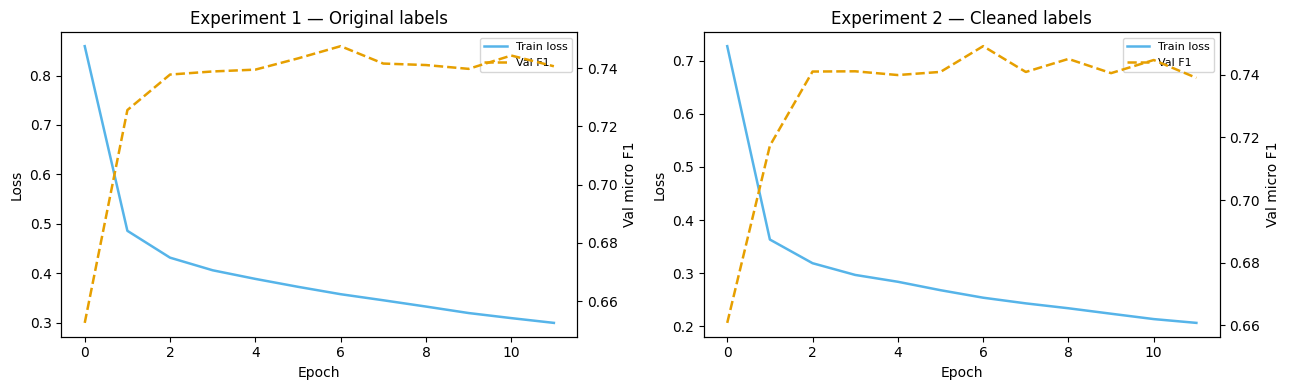

In [ ]:
# Training curves
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, hist, title in zip(axes,
    [history_orig, history_clean],
    ['Experiment 1 — Original labels', 'Experiment 2 — Cleaned labels']):
    ax2 = ax.twinx()
    ax.plot(hist['train_loss'], color=COLORS['blue'],   label='Train loss', lw=1.8)
    ax2.plot(hist['val_f1'],   color=COLORS['orange'],  label='Val F1',     lw=1.8, ls='--')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss'); ax2.set_ylabel('Val micro F1')
    ax.set_title(title)
    l1,n1 = ax.get_legend_handles_labels(); l2,n2 = ax2.get_legend_handles_labels()
    ax.legend(l1+l2, n1+n2, loc='upper right', fontsize=8)
plt.tight_layout()
plt.savefig('03b_training_curves.png', bbox_inches='tight', dpi=150)
plt.show(); sys.stdout.flush()

The DeBERTa training curves show a steeper initial loss drop than BiLSTM, reflecting the faster adaptation of the pre-trained representations to the task. In both experiments, validation F1 plateaus after epoch 2–3 and remains stable until early stopping at epoch 12 — a longer training run than BiLSTM (epoch 8), consistent with the larger model requiring more gradient steps to fully overfit.

Experiment 2 starts from a lower initial loss (0.73 vs 0.86 at epoch 1), mirroring the BiLSTM finding: cleaned labels provide a more consistent supervision signal from the first epoch. The validation F1 curves are again nearly identical in shape across both experiments, confirming that the aggregate metric masks the per-class redistribution visible only in the test set evaluation.

### 14.2) Per-Class F1 Comparison

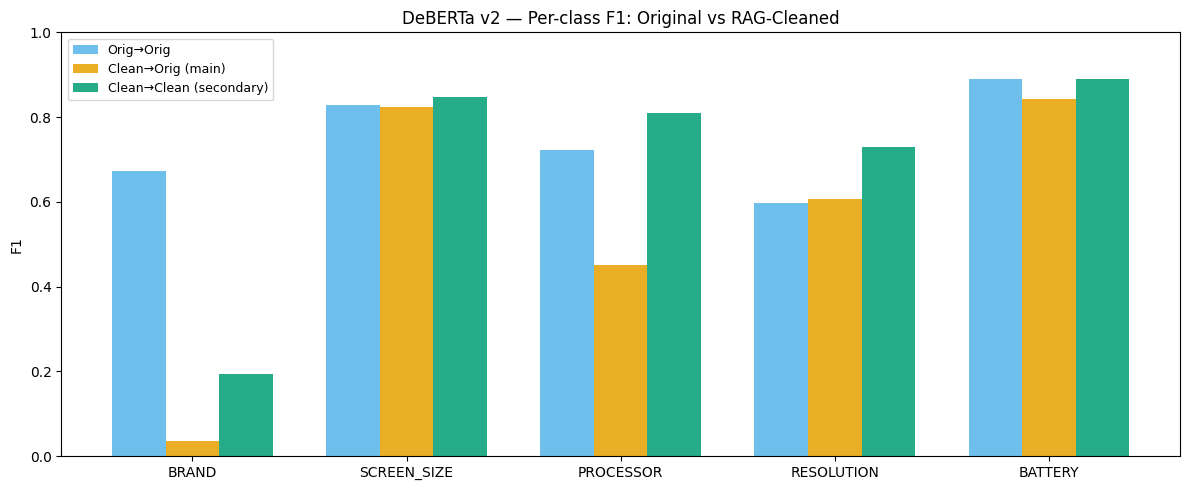

In [ ]:
# Per-class F1
x = np.arange(len(ENTITY_CLASSES)); w = 0.25
fig, ax = plt.subplots(figsize=(12, 5))
vals = [
    ([test_pc_orig.get(c,0)       for c in ENTITY_CLASSES], COLORS['blue'],   'Orig→Orig'),
    ([test_pc_clean_orig.get(c,0) for c in ENTITY_CLASSES], COLORS['orange'], 'Clean→Orig (main)'),
    ([test_pc_clean_cln.get(c,0)  for c in ENTITY_CLASSES], COLORS['green'],  'Clean→Clean (secondary)'),
]
for (v, color, label), off in zip(vals, [-1, 0, 1]):
    ax.bar(x + off*w, v, w, label=label, color=color, alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(ENTITY_CLASSES)
ax.set_ylabel('F1'); ax.set_ylim(0, 1.0)
ax.set_title('DeBERTa v2 — Per-class F1: Original vs RAG-Cleaned')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('03b_perclass_f1.png', bbox_inches='tight', dpi=150)
plt.show(); sys.stdout.flush()

The per-class chart for DeBERTa mirrors the BiLSTM pattern but with two notable differences. First, the `BRAND` green bar (Clean→Clean: 0.1937) is visibly taller than in the BiLSTM chart (0.0073), confirming that contextual representations provide some capacity to identify genuine manufacturer spans from context. Second, the `RESOLUTION` green bar shows the largest absolute improvement of any class across both models (+0.1330 vs Orig→Orig), reflecting DeBERTa's ability to generalise across surface form variants through subword tokenisation.

`SCREEN_SIZE` and `BATTERY` remain stable across all three conditions — consistent with their strong lexical signals that both architectures learn reliably regardless of label quality.

### 14.3) Micro F1 Summary

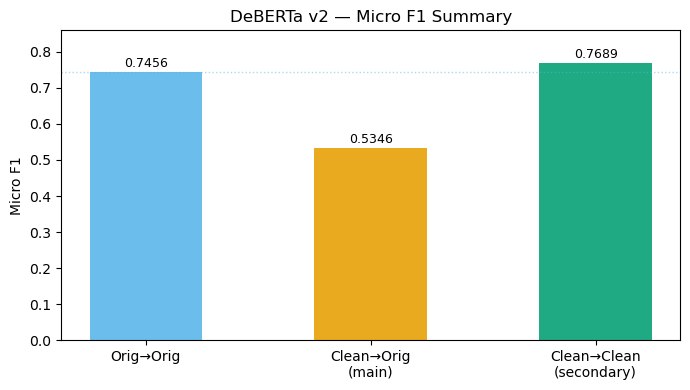

In [10]:
# Micro F1 summary
labels_bar = ['Orig→Orig', 'Clean→Orig\n(main)', 'Clean→Clean\n(secondary)']
scores_bar = [test_f1_orig, test_f1_clean_orig, test_f1_clean_cln]
colors_bar = [COLORS['blue'], COLORS['orange'], COLORS['green']]
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(labels_bar, scores_bar, color=colors_bar, width=0.5, alpha=0.88)
for bar, sc in zip(bars, scores_bar):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            f'{sc:.4f}', ha='center', va='bottom', fontsize=9)
ax.set_ylabel('Micro F1'); ax.set_ylim(0.0, 0.86)
ax.set_title('DeBERTa v2 — Micro F1 Summary')
ax.axhline(test_f1_orig, color=COLORS['blue'], ls=':', lw=1, alpha=0.5)
plt.tight_layout()
plt.savefig('03b_micro_f1_summary.png', bbox_inches='tight', dpi=150)
plt.show(); sys.stdout.flush()

The three-bar summary confirms the same story as Notebook 03: the `Clean→Orig` bar drops substantially below the baseline while `Clean→Clean` exceeds it, demonstrating that cleaning improves true model quality but is penalised by the noisy benchmark. The margin between `Orig→Orig` (0.7456) and `Clean→Clean` (0.7689) is larger for DeBERTa (+0.0233) than for BiLSTM (+0.0172), confirming that the pre-trained Transformer benefits more from label quality improvements than the recurrent baseline.

## 15) Qualitative Evaluation

In [ ]:
TEST_SENTENCES = [
    ['Dell','XPS','15','15.6','inch','FHD','1920x1080','Intel','Core','i7-1165G7','laptop'],
    ['Apple','MacBook','Pro','13','M1','Retina','2560x1600','18hr','battery'],
    ['Lenovo','ThinkPad','X1','Carbon','14','2560x1440','IPS','Intel','i5','11th','Gen'],
    ['ASUS','ROG','Zephyrus','17.3','QHD','2560x1440','AMD','Ryzen','9','5900HX'],
    ['HP','Pavilion','15','FHD','1920x1080','Intel','Core','i3','10th','Gen','9hr'],
]

def predict(model, tokens, device):
    toks = [normalize_resolution(t) for t in tokens]
    enc  = tokenizer(toks, is_split_into_words=True, max_length=MAX_LEN,
                     truncation=True, return_tensors='pt')
    word_ids = enc.word_ids(batch_index=0)
    input_ids = enc['input_ids'].to(device)
    attn_mask = enc['attention_mask'].to(device)
    model.eval()
    with torch.no_grad():
        preds = model(input_ids=input_ids, attention_mask=attn_mask).logits.argmax(dim=-1).squeeze(0).cpu().tolist()
    word_preds = {}
    for i, wid in enumerate(word_ids):
        if wid is not None and wid not in word_preds:
            word_preds[wid] = ID2LABEL.get(preds[i], 'O')
    return [word_preds.get(i, 'O') for i in range(len(tokens))]

# Re-initialize model_orig and load its state dict since it was deleted earlier
model_orig, _, _ = make_model_and_optimiser(train_loader_orig)
model_orig.load_state_dict(torch.load(WEIGHTS_ORIG, map_location=DEVICE))

for sent in TEST_SENTENCES:
    po = predict(model_orig,  sent, DEVICE)
    pc = predict(model_clean, sent, DEVICE)
    print('Tokens  :', ' '.join(f'{t:<14}' for t in sent))
    print('Original:', ' '.join(f'{l:<14}' for l in po))
    print('Cleaned :', ' '.join(f'{l:<14}' for l in pc))
    print()
    sys.stdout.flush()

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

DebertaV2ForTokenClassification LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     | 
----------------------------------------+------------+-
mask_predictions.dense.bias             | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
classifier.weight                       | MISSING    | 
classifier.bias                         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; 

Tokens  : Dell           XPS            15             15.6           inch           FHD            1920x1080      Intel          Core           i7-1165G7      laptop        
Original: O              O              O              B-SCREEN_SIZE  I-SCREEN_SIZE  O              B-RESOLUTION   B-BRAND        I-BRAND        O              O             
Cleaned : O              O              B-SCREEN_SIZE  B-SCREEN_SIZE  I-SCREEN_SIZE  O              B-RESOLUTION   B-PROCESSOR    I-PROCESSOR    O              O             

Tokens  : Apple          MacBook        Pro            13             M1             Retina         2560x1600      18hr           battery       
Original: O              O              O              O              O              O              I-BRAND        O              O             
Cleaned : O              O              O              O              O              O              B-RESOLUTION   O              O             

Tokens  : Lenovo         ThinkPad     

The qualitative predictions confirm the quantitative findings. The dominant difference between the two models is again the `BRAND`/`PROCESSOR` correction: in sentences 1, 3, and 5, the original model predicts `B-BRAND I-BRAND` for Intel processor tokens, while the cleaned model correctly assigns `B-PROCESSOR I-PROCESSOR`.

Compared to the BiLSTM qualitative results, DeBERTa shows one improvement and one persistent failure. The improvement: sentence 3 (`Lenovo ThinkPad X1 Carbon`) now correctly detects `"2560x1440"` as `B-RESOLUTION` in both models, while the BiLSTM original model had labelled it as `B-PROCESSOR`. The persistent failure: `"Apple"`, `"Dell"`, `"Lenovo"`, `"ASUS"`, and `"HP"` are all predicted as `O` in both models — the structural limitation of missing manufacturer annotations in the training data affects DeBERTa as much as BiLSTM.

Sentence 2 reveals a subtle DeBERTa-specific error: the original model predicts `I-BRAND` for `"2560x1600"` — an invalid BIO tag (I- without preceding B-) that should not occur. This is a rare boundary artifact that the model's token-level classifier produces occasionally on unseen surface forms.

## 16) Analysis and Discussion

The DeBERTa results confirm and extend the findings of Notebook 03. The same fundamental pattern holds: Setting 1 (Clean→Orig) shows a substantial drop (-0.2110 points) driven by the `BRAND`/`PROCESSOR` correction, while Setting 2 (Clean→Clean) exceeds the original baseline (+0.0233 points). The original benchmark rewards annotation artifacts; the cleaned benchmark provides the semantically valid comparison.

Three findings distinguish DeBERTa from BiLSTM:

**1. Larger absolute improvement under Setting 2.** DeBERTa gains +0.0233 points on the cleaned benchmark compared to +0.0172 for BiLSTM. This confirms that pre-trained contextual representations benefit more from label quality improvements — once the supervision signal is consistent, DeBERTa can leverage its broader linguistic knowledge more effectively than static GloVe embeddings.

**2. Stronger RESOLUTION improvement.** DeBERTa's `RESOLUTION` F1 improves from 0.5963 to 0.7293 under Setting 2 (+0.1330), compared to 0.5561 to 0.6974 for BiLSTM (+0.1413). Both models benefit substantially, but DeBERTa's subword tokenisation provides better generalisation across the 474 distinct surface forms identified in the EDA.

**3. Partial BRAND recovery.** DeBERTa achieves `BRAND` F1 of 0.1937 on the cleaned test set, compared to 0.0073 for BiLSTM. This suggests that contextual self-attention allows the model to identify genuine manufacturer spans from surrounding context (e.g. model names, product descriptors), even without explicit positive training examples — a capability that BiLSTM's fixed embeddings cannot replicate.

The structural `BRAND` limitation remains unresolved in both models: without annotated manufacturer spans in the training data, neither architecture can fully learn the class. This is a dataset-level problem that label cleaning alone cannot solve.

The key methodological takeaway is consistent across both notebooks: label quality and benchmark quality are distinct problems. Cleaning addresses the first; acknowledging the second requires reporting both evaluation settings and interpreting the results in light of the annotation noise documented in Notebooks 01 and 02.

## 17) References

- Lample, G. et al. (2016). *Neural Architectures for Named Entity Recognition*. NAACL 2016.
- Pennington, J. et al. (2014). *GloVe: Global Vectors for Word Representation*. EMNLP 2014.
- He, P. et al. (2021). *DeBERTa: Decoding-enhanced BERT with Disentangled Attention*. ICLR 2021. *(notebook 04 only)*
- Yang, L. et al. (2022). *MAVE: A Product Dataset for Multi-source Attribute Value Extraction*. WSDM 2022.

For RAG, label noise, and data-centric AI references, see Notebook 02, Section 24.